# INSTITUTO POLITÉCNICO DE LEIRIA
## Mestrado em Ciência de Dados - Data Mining
### Estudantes: Jose Luna, Juan Barrezueta e Luis Villacis

Este dataset ('lung disease classification') mostra un dataset de imagenes de rayos x del chest de personas con corona virus, tuberculosis y normales, en el presente proyecto se espera utilizar tecnicas de deep learning para la clasificacion de las imagenes.


Para la primera parte del proyecto se recolectara la informacion de la base de datos utilizada, el cual ya tenia dividio los datos en entramiento, validacion y test 

In [2]:
#Showing directories’ size
import os, shutil

train_dir ='./images/train'
validation_dir = './images/val'
test_dir = './images/test'

train_corona_virus_d = './images/train/Corona_Virus_Disease'
train_normal = './images/train/Normal'
train_tuberculosis= './images/train/Tuberculosis'

val_corona_virus_d = './images/val/Corona_Virus_Disease'
val_normal = './images/val/Normal'
val_tuberculosis= './images/val/Tuberculosis'

test_corona_virus_d = './images/test/Corona_Virus_Disease'
test_normal = './images/test/Normal'
test_tuberculosis= './images/test/Tuberculosis'


print('total train corona virus images:', len(os.listdir(train_corona_virus_d)))
print('total train normal images:', len(os.listdir(train_normal)))
print('total train tuberculosis images:', len(os.listdir(train_tuberculosis)))


print('total validation corona virus images:', len(os.listdir(val_corona_virus_d)))
print('total validation normal images:', len(os.listdir(val_normal)))
print('total validation tuberculosis images:', len(os.listdir(val_tuberculosis)))


print('total testing organic corona virus img:', len(os.listdir(test_corona_virus_d)))
print('total testing recicle normal imgs:', len(os.listdir(test_normal)))
print('total testing recicle tuberculosis img:', len(os.listdir(test_tuberculosis)))

total train corona virus images: 1218
total train normal images: 1207
total train tuberculosis images: 1220
total validation corona virus images: 406
total validation normal images: 402
total validation tuberculosis images: 406
total testing organic corona virus img: 407
total testing recicle normal imgs: 404
total testing recicle tuberculosis img: 408


de ahi se prepara un conjunto de datos para un modelo de aprendizaje automático utilizando la biblioteca Keras en Python. Se especifica el tamaño de las imágenes y se configuran los lotes para los conjuntos de entrenamiento, validación y prueba. Cada conjunto utiliza un tamaño de lote y una semilla para el orden aleatorio específicos, asegurando que los datos estén listos para el entrenamiento del modelo. Este proceso es un paso esencial antes de comenzar el entrenamiento real del modelo.



In [3]:
from keras.utils import image_dataset_from_directory

IMG_SIZE = 150
train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    label_mode='categorical',
    seed = 100
)

validation_dataset = image_dataset_from_directory(
    validation_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    label_mode='categorical',
    seed = 100
)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    label_mode='categorical',
    seed = 100
)

Found 3645 files belonging to 3 classes.
Found 1214 files belonging to 3 classes.
Found 1219 files belonging to 3 classes.


Para analizar como se encuentra nuestro dataset procedemos a mostrar las primeras 5 imagenes del batch

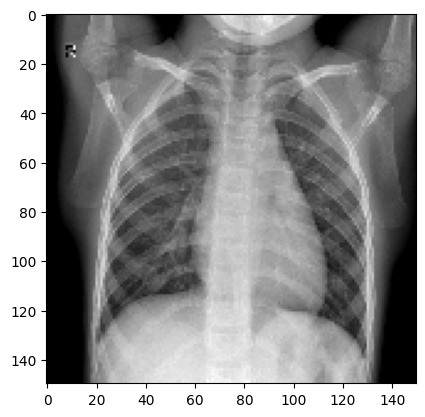

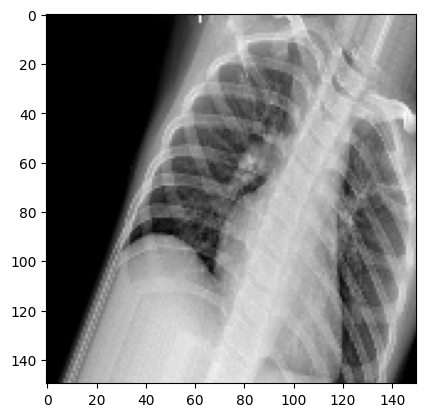

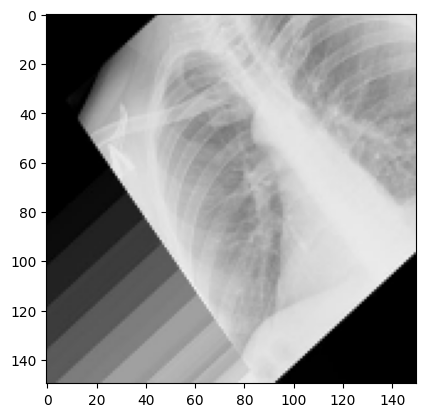

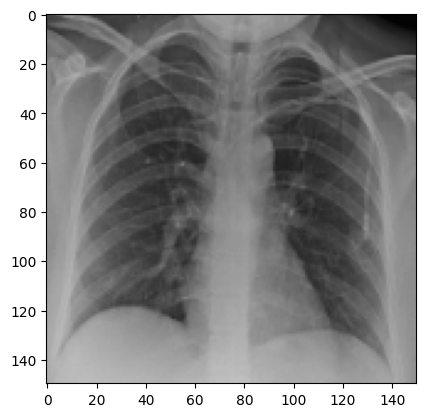

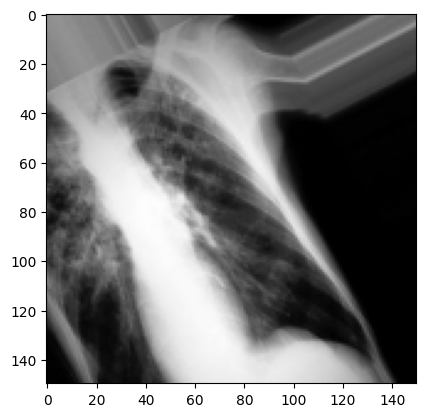

In [4]:
#Viewing the first 5 images of the first batch
import matplotlib.pyplot as plt
for data_batch, _ in train_dataset.take(1):
    for i in range(5):
        plt.imshow(data_batch[i].numpy().astype("uint8"))
        plt.show()

NameError: name 'shape' is not defined

 El siguiente script se contruye las capas, la capa de entrada del modelo con el tamaño de imagen y los canales de color como se verifico en el paso anterior, se toma el tamaño de la imagen 150 y se rescala a 1/255 de cada imagen para normalizar los valores de los píxeles. Se añade una capa convolucional con un filtro de 7x7 (este valor se saco mediante prueba y erro con respecto al modelo siendo el valor de 32 el valor que mejores condiciones demostraron) y un tamaño de feuture map igual a 32 
 $$\cfrac{W -F +2P  }{S} +1$$
$$\cfrac{150 -7 +2\times0  }{1}  +1$$
$$144$$
En donde sus parametros son 
$$ FM\times(F \times F \times FMP +1 ) $$

$$ 32\times(7 \times 7 \times 3 +1 ) $$

$$4736$$

Una vez realizada la capa de convolucion se añade una capa de normalización por Lotes de ahi se aumenta una capa  agrupamiento para reducir la dimensionalidad a traves del MaxPooling2D. 

$$\cfrac{144}{2}$$
$$72$$

Despues se añade otra capa convolucional, en donde se cambio el filtro a un filtro de 5x5 y los feature maps igual a 64
 $$\cfrac{W -F +2P  }{S} +1$$
$$\cfrac{72 -5 +2\times0  }{1}  +1$$
$$68$$

En donde sus parametros son 
$$ FM\times(F \times F \times FMP +1 ) $$

$$ 64\times(5 \times 5 \times 32 +1 ) $$

$$51264$$
se aplico otra capa de capa de normalización por Lotes y de agrupamiento para reducir la dimensionalidad a traves del MaxPooling2D. 

$$\cfrac{68}{2}$$
$$34$$
En la siguiente capa convolucional:
 $$\cfrac{W -F +2P  }{S} +1$$
$$\cfrac{34 -5 +2\times0  }{1}  +1$$
$$30$$

En donde sus parametros son 
$$ FM\times(F \times F \times FMP +1 ) $$

$$ 128\times(5 \times 5 \times 64 +1 ) $$

$$204928$$

Se aplico otra capa de capa de normalización por Lotes y de agrupamiento 
$$\cfrac{30}{2}$$
$$15$$

En la siguiente capa convolucional filtro 3x3 feuter maps 256:
 $$\cfrac{W -F +2P  }{S} +1$$
$$\cfrac{15 -3 +2\times0  }{1}  +1$$
$$13$$

En donde sus parametros son 
$$ FM\times(F \times F \times FMP +1 ) $$

$$ 256\times(3 \times 3 \times 128 +1 ) $$

$$295168$$


En la siguiente capa de agrupamiento 
$$\cfrac{13}{2}$$
$$6$$

Una vez llegado a este punto para la capa de salida se procedio a poner todas la neuronas donde aplana la entrada multidimensional en un vector unidimensional con valor de 
 $$6\times6\times 256$$
  $$9216$$



Despues de realizado el vector unidimensional, se procede a conectar la capa densa, dada la bibliografia, y mediante prueba y error se llego a la conclusion de que el parametro es:

$$2^11=2048$$

En donde sus parametros son 
$$ Salidas de la capa anterior \times neuronas de la capa densa \times FMP + numero de neuronas  $$

$$ (9216 \times 2048 +2048 ) $$

$$18876416$$

Se normaliza y por ultimo se conecta a las neuronas de salida con un valor de  3

$$ Salidas de la capa anterior \times neuronas de la capa densa \times FMP + numero de neuronas  $$

$$ (2048 \times 3 +3 ) $$

$$6147$$


In [9]:
from tensorflow import keras
from keras import layers
from keras import models
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Rescaling(1./255)(inputs)
# x = layers.Conv2D(filters=32, kernel_size=12, activation="relu")(x)
# x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=32, kernel_size=7, activation="relu")(x)
x = layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True)(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=64, kernel_size=5, activation="relu")(x)
x = layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True)(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=128, kernel_size=5, activation="relu")(x)
x = layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True)(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True)(x)
x = layers.MaxPooling2D(pool_size=2)(x)

# x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
# x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Flatten()(x)
x = layers.Dense(2048, activation="relu")(x)
x = layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True)(x)

outputs = layers.Dense(3, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 144, 144, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 144, 144, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 72, 72, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 68, 68, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 68, 68, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │    18,876,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,448,771 (74.19 MB)

 Trainable params: 19,443,715 (74.17 MB)

 Non-trainable params: 5,056 (19.75 KB)

In [10]:
inputs

<KerasTensor shape=(None, 150, 150, 3), dtype=float32, sparse=None, name=keras_tensor>

Para la compilacion del modelo se utiliza ccomo perdida la entropia cruzada categorica que es utilizada en clasificacion multiclase, dado el sistema a analizar se utiliza un optimizador RMS con una tasa de aprendizade de $1 \times 10^{-7}$  y como metrica de rendimiento se considera el accuaracy.

In [53]:
import tensorflow as tf
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-7),
    metrics=['acc'])

Para evitar el sobreajuste del modelo se procedio a utilizar calbacks con las siguientes configuraciones, se parara si el val_loss deja de mejorar por 10 epocas. y atraves de modelcheckpoint guardaremos el mejor modelo de cada epoca.

In [55]:
callbacks_list = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10),
    keras.callbacks.ModelCheckpoint(filepath="best_model.keras", save_best_only=True,monitor='val_loss')
]

In [57]:
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    verbose=1,
    callbacks=callbacks_list
)

Epoch 1/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 37s 304ms/step - acc: 0.4101 - loss: 1.3896 - val_acc: 0.3311 - val_loss: 1.1175
Epoch 2/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 35s 304ms/step - acc: 0.5543 - loss: 1.0676 - val_acc: 0.2941 - val_loss: 1.1345
Epoch 3/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 36s 315ms/step - acc: 0.6227 - loss: 0.8982 - val_acc: 0.4102 - val_loss: 1.2374
Epoch 4/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 33s 290ms/step - acc: 0.6805 - loss: 0.7815 - val_acc: 0.4794 - val_loss: 1.1165
Epoch 5/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 34s 297ms/step - acc: 0.7031 - loss: 0.7071 - val_acc: 0.6590 - val_loss: 0.7854
Epoch 6/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 35s 306ms/step - acc: 0.7381 - loss: 0.6472 - val_acc: 0.7364 - val_loss: 0.6317
Epoch 7/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 36s 312ms/step - acc: 0.7642 - loss: 0.5929 - val_acc: 0.7496 - val_loss: 0.5796
Epoch 8/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 41s 355ms/step - acc: 0.7747 - loss: 0.5717 - val_acc: 0.7718 - val_loss: 0.5527
Epoch 9/30
114/114 ━━━━━━━━━━━━━

In [59]:
model.save('./Batch_Norm_Categorical_Model_xray.keras')

In [61]:
keras.models.load_model('./Batch_Norm_Categorical_Model_xray.keras')

<Functional name=functional_1, built=True>

In [63]:
val_loss, val_acc = model.evaluate(validation_dataset)
print('val_acc:', val_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - acc: 0.8684 - loss: 0.3238
val_acc: 0.8690280318260193


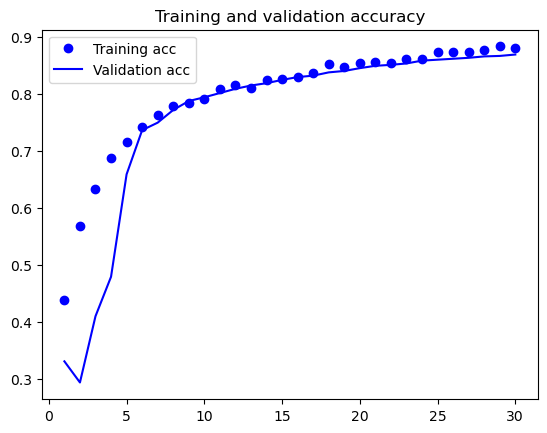

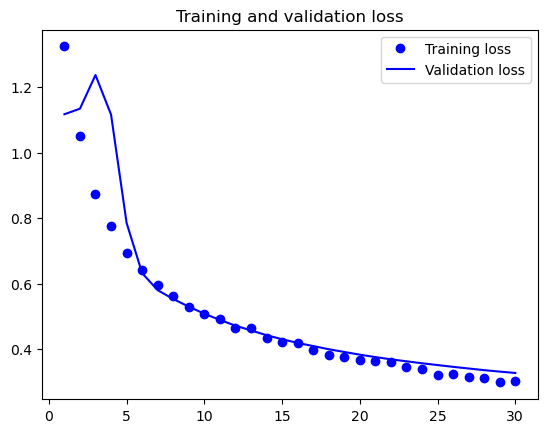

In [65]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Como se puede ver en ;as imagenes anteriores, en primera tenemos un buen manejo de los datos de entrenamiento y validacion, dado que aun no se encuentra aplanada la curva, se requeruiera mas epocas para llegar al mejor modelo. 

In [31]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import to_categorical

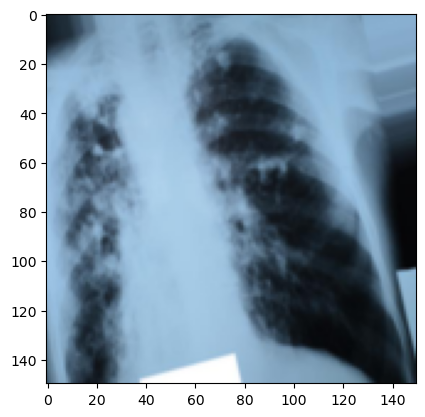

(1, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Class index: [2]
One-hot encoded prediction: [[0. 0. 1.]]


In [35]:
# img = tf.keras.preprocessing.image.load_img('./train/cats/cat.1.jpg', target_size=(150, 150), interpolation='bilinear')
img = tf.keras.preprocessing.image.load_img('images/val/Tuberculosis/test_0_274.jpeg', target_size=(150, 150), interpolation='bilinear')
plt.imshow(img)
plt.show()
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
print(img_array.shape)
result = model.predict(img_array)

# Convert prediction to class index (0, 1, 2)
class_index = np.argmax(result, axis=1)

# Convert class index to one-hot encoded vector
one_hot_prediction = to_categorical(class_index, num_classes=3)

# Print the result
print("Class index:", class_index)
print("One-hot encoded prediction:", one_hot_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━

2024-07-01 17:50:33.127800: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


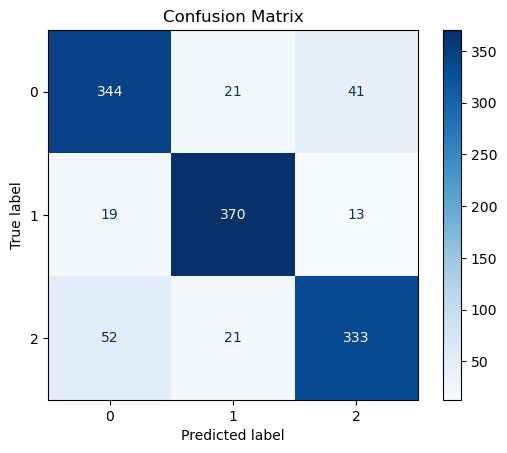

Classification Report:
                       precision    recall  f1-score   support

Corona_Virus_Disease       0.83      0.85      0.84       406
              Normal       0.90      0.92      0.91       402
        Tuberculosis       0.86      0.82      0.84       406

            accuracy                           0.86      1214
           macro avg       0.86      0.86      0.86      1214
        weighted avg       0.86      0.86      0.86      1214



In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


# Inicializar listas para almacenar etiquetas verdaderas y predicciones
true_labels = []
predictions = []

# Iterar a través del conjunto de validación y predecir
for images, labels in validation_dataset:
    preds = model.predict(images)
    predictions.extend(preds)
    true_labels.extend(labels.numpy())

# Convertir las listas a arrays de numpy
predictions = np.array(predictions)
true_labels = np.array(true_labels)

# Si las etiquetas verdaderas están en formato one-hot encoded, convertirlas a etiquetas enteras
if true_labels.ndim == 2 and true_labels.shape[1] > 1:
    true_labels_int = np.argmax(true_labels, axis=1)
else:
    true_labels_int = true_labels

# Asegurarse de que las predicciones son probabilidades y luego convertirlas a etiquetas enteras
predictions_int = np.argmax(predictions, axis=1)

# Crear la matriz de confusión
cm = confusion_matrix(true_labels_int, predictions_int)

# Mostrar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Generar y mostrar el reporte de clasificación
report = classification_report(true_labels_int, predictions_int, target_names=validation_dataset.class_names)
print("Classification Report:\n", report)

Para comprobar los resultados obtenidos, se procedio a realizar una matriz de confusion, en donde se analizo la precicion y el recall de las diferentes imagenes de validacion